Постановка задачи
Определить, какая грань кубсата (+X, -X, +Y, -Y, +Z, -Z) наиболее видна на изображении на основе визуальных признаков.

парсинг датасета с ленивой загрузкой

In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import glob
from functools import lru_cache

class CubeSatFaceDatasetLazy(Dataset):
    def __init__(self, root_dir, mode='train', sequence=None, transform=None, cache_size=100):
        """
        Args:
            root_dir (str): Корневая директория датасета (synthetic_cubesat)
            mode (str): 'train', 'test' для dataset или None для sequence
            sequence (str): 'a', 'b', 'c' для sequential данных
            transform: Трансформации изображений
            cache_size (int): Размер кэша для загруженных изображений
        """
        self.root_dir = root_dir
        self.mode = mode
        self.sequence = sequence
        self.transform = transform
        self.cache_size = cache_size
        self._image_cache = {}
        
        if sequence is not None:
            self.data_dir = os.path.join(root_dir, f'sequence_{sequence}')
            self.gt_file = os.path.join(self.data_dir, 'ground_truth.csv')
            self.images_dir = os.path.join(self.data_dir, 'images')
        else: # Random
            self.data_dir = os.path.join(root_dir, 'dataset', mode)
            self.gt_file = os.path.join(self.data_dir, f'{mode}_ground_truth.csv')
            self.images_dir = os.path.join(self.data_dir, 'images')
        
        self.gt_df = pd.read_csv(self.gt_file)
        print(f"Загружен ground truth файл: {self.gt_file}")
        print(f"Колонки в ground truth: {list(self.gt_df.columns)}")
        print(f"Всего записей в ground truth: {len(self.gt_df)}")
        self.image_files = self._get_image_files()
        print(f"Найдено изображений: {len(self.image_files)}")
        
        self._match_images_with_groundtruth()
        
        self.face_normals = {
            '+X': np.array([1, 0, 0]),
            '-X': np.array([-1, 0, 0]),
            '+Y': np.array([0, 1, 0]),
            '-Y': np.array([0, -1, 0]),
            '+Z': np.array([0, 0, 1]),
            '-Z': np.array([0, 0, -1])
        }
        self.face_labels = {
            '+X': 0, '-X': 1,
            '+Y': 2, '-Y': 3,
            '+Z': 4, '-Z': 5
        }
        
        self.label_to_face = {v: k for k, v in self.face_labels.items()}
        
        print("Вычисление меток видимых граней...")
        self.labels = self._compute_labels()
        print(f"Режим: {mode if mode else 'sequential'}, последовательность: {sequence if sequence else 'N/A'}")
        self._reset_cache_stats()

    
    def _get_image_files(self):
        extensions = ['*.jpg', '*.png']
        all_files = []
        for ext in extensions:
            files = glob.glob(os.path.join(self.images_dir, ext))
            all_files.extend(files)
        
        all_files.sort()
        def extract_number(filename):
            base = os.path.basename(filename)
            num_str = ''.join(filter(str.isdigit, base))
            return int(num_str) if num_str else 0
        
        if all('img_' in f for f in all_files[:5]):
            all_files.sort(key=extract_number)
        
        return all_files

    
    def _match_images_with_groundtruth(self):
        if len(self.image_files) != len(self.gt_df):
            print(f"Неоответствие: изображений {len(self.image_files)}, записей в ground truth {len(self.gt_df)}")
            
            min_len = min(len(self.image_files), len(self.gt_df))
            self.image_files = self.image_files[:min_len]
            self.gt_df = self.gt_df.iloc[:min_len].reset_index(drop=True)
            print(f"Ограничено до {min_len} записей")

    
    def _load_image_lazy(self, img_path, target_size=None):
        cache_key = img_path
        if cache_key in self._image_cache:
            self._cache_hits += 1
            return self._image_cache[cache_key]
        self._cache_misses += 1
        
        try:
            with Image.open(img_path) as img:
                img = img.convert('RGB')
                if target_size:
                    img = img.resize(target_size, Image.Resampling.LANCZOS)
                
                if len(self._image_cache) < self.cache_size:
                    self._image_cache[cache_key] = img
                else:
                    # Если кэш полон, удаляем самый старый элемент
                    if self._image_cache:
                        oldest_key = next(iter(self._image_cache))
                        del self._image_cache[oldest_key]
                    self._image_cache[cache_key] = img
                
                return img
                
        except Exception as e:
            print(f"Ошибка загрузки изображения {img_path}: {e}")
            # Возвращаем черное изображение в случае ошибки
            return Image.new('RGB', (256, 256), color='black')

    
    def _reset_cache_stats(self):
        self._cache_hits = 0
        self._cache_misses = 0

    
    def get_cache_stats(self):
        return {
            'hits': self._cache_hits,
            'misses': self._cache_misses,
            'hit_rate': self._cache_hits / (self._cache_hits + self._cache_misses) 
                        if (self._cache_hits + self._cache_misses) > 0 else 0,
            'cache_size': len(self._image_cache)
        }

        
    def _compute_labels(self):
        labels = []
        
        for idx in range(len(self.gt_df)):
            row = self.gt_df.iloc[idx]
            
            try:
                # Структура: ['IMG_NUM', 'X', 'Y', 'Z', 'ROLL', 'PITCH', 'YAW', 'Q1', 'Q2', 'Q3', 'W']
                position = np.array([
                    float(row['X']),  
                    float(row['Y']),   
                    float(row['Z'])  
                ])
                
                # Формат: [x, y, z, w]  x,y,z - векторы, w - скаляр
                orientation = np.array([
                    float(row['Q1']),  # x компонента
                    float(row['Q2']),  # y компонента
                    float(row['Q3']),  # z компонента
                    float(row['W'])    # w (scalar) компонента
                ])
                
                orientation_norm = np.linalg.norm(orientation)
                if orientation_norm > 0:
                    orientation = orientation / orientation_norm
                face_label = self._get_most_visible_face(position, orientation)
                labels.append(face_label)
                
            except Exception as e:
                print(f"Ошибка при обработке строки {idx}: {e}")
                labels.append(0)  
        
        return labels

        
    def _get_most_visible_face(self, position, orientation):
        norm = np.linalg.norm(position)
        if norm > 0:
            camera_direction = -position / norm
        else:
            camera_direction = np.array([0, 0, -1])
        
        try:
            rotation = R.from_quat(orientation)
            rot_matrix = rotation.as_matrix()
        except Exception as e:
            print(f'{e} \n {orientation}')
            return 0
        
        max_dot = -np.inf
        best_face = '+X'
        for face_name, normal_local in self.face_normals.items():
            normal_camera = rot_matrix @ normal_local
            normal_camera_norm = np.linalg.norm(normal_camera)
            if normal_camera_norm > 0:
                normal_camera = normal_camera / normal_camera_norm
            
            dot_product = np.dot(normal_camera, camera_direction)
            
            if dot_product > max_dot:
                max_dot = dot_product
                best_face = face_name
        
        return self.face_labels[best_face]

    
    def __len__(self):
        return len(self.image_files)

    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = self._load_image_lazy(img_path)
        if self.transform:
            image = self.transform(image)
        
        label = self.labels[idx]
        return image, label
    

    def get_face_name(self, label_idx):
        return self.label_to_face[label_idx]
    
    
    def get_sample_info(self, idx):
        row = self.gt_df.iloc[idx]
        return {
            'image_path': self.image_files[idx],
            'label': self.labels[idx],
            'face_name': self.get_face_name(self.labels[idx]),
            'position': [float(row['X']), float(row['Y']), float(row['Z'])],
            'orientation': [float(row['Q1']), float(row['Q2']), float(row['Q3']), float(row['W'])],
        }

        
print("DONE")

DONE


Создание DataLoader с оптимизациями


Создание датасета с ленивой загрузкой...
Загружен ground truth файл: ./synthetic_cubesat\dataset\train\train_ground_truth.csv
Колонки в ground truth: ['IMG_NUM', 'X', 'Y', 'Z', 'ROLL', 'PITCH', 'YAW', 'Q1', 'Q2', 'Q3', 'W']
Всего записей в ground truth: 7998
Найдено изображений: 7998
Вычисление меток видимых граней...
Режим: train, последовательность: N/A
Датасет создан за 1.63 секунд

Разделение на тренировочную и валидационную части...
Тренировочных семплов: 6398 (80%)
Валидационных семплов: 1600 (20%)

Анализ распределения классов:
Полный тренировочный адтасет:
  +X (класс 0): 2148 (26.9%)
  -X (класс 1): 2130 (26.6%)
  +Y (класс 2): 927 (11.6%)
  -Y (класс 3): 936 (11.7%)
  +Z (класс 4): 892 (11.2%)
  -Z (класс 5): 965 (12.1%)
Тренировочный адтасет:
  +X (класс 0): 1721 (26.9%)
  -X (класс 1): 1677 (26.2%)
  +Y (класс 2): 736 (11.5%)
  -Y (класс 3): 764 (11.9%)
  +Z (класс 4): 716 (11.2%)
  -Z (класс 5): 784 (12.3%)
Валидационный адтасет:
  +X (класс 0): 427 (26.7%)
  -X (класс 1)

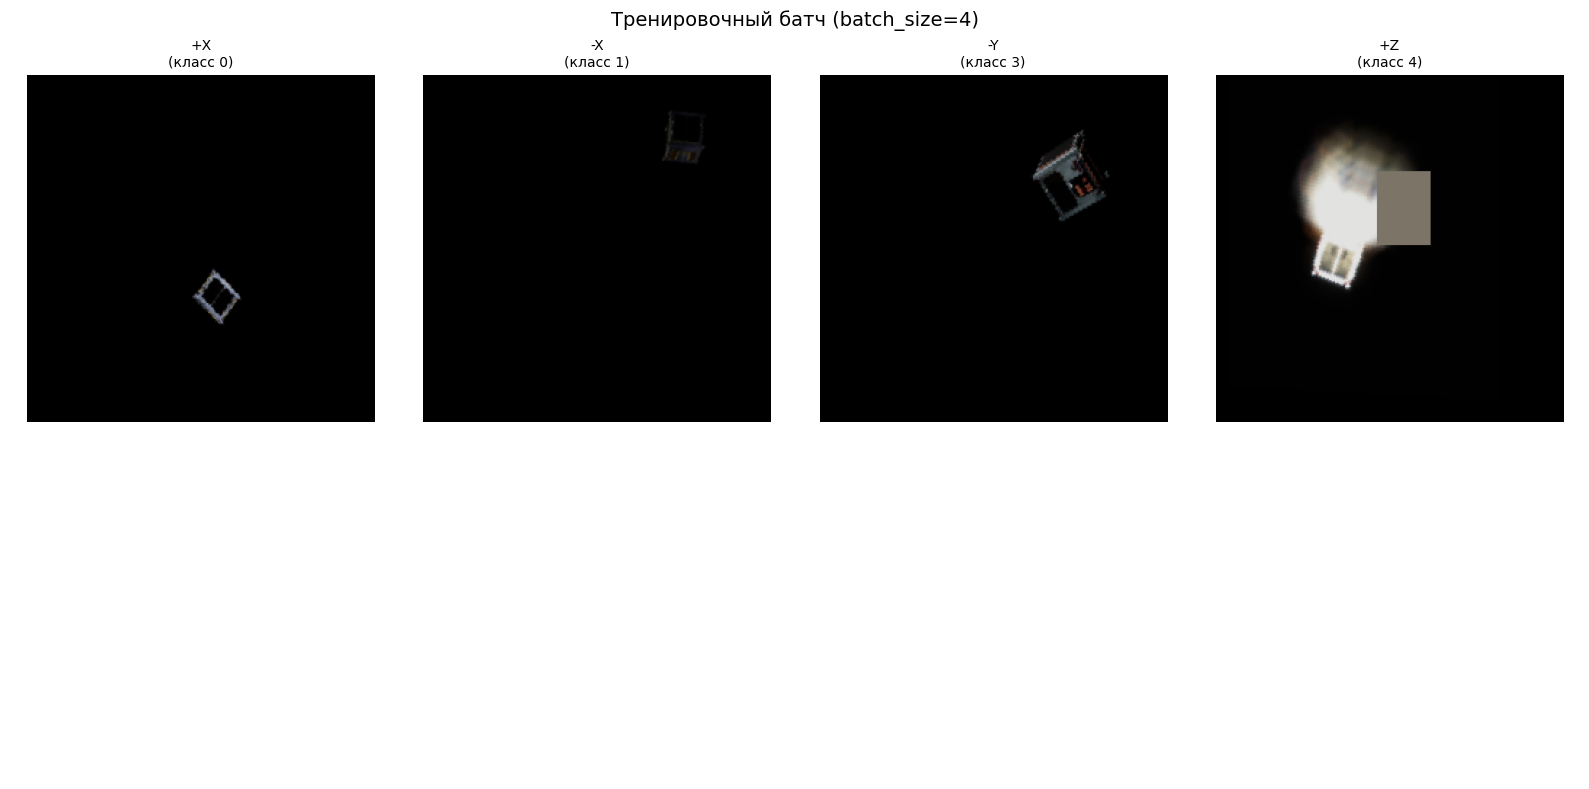

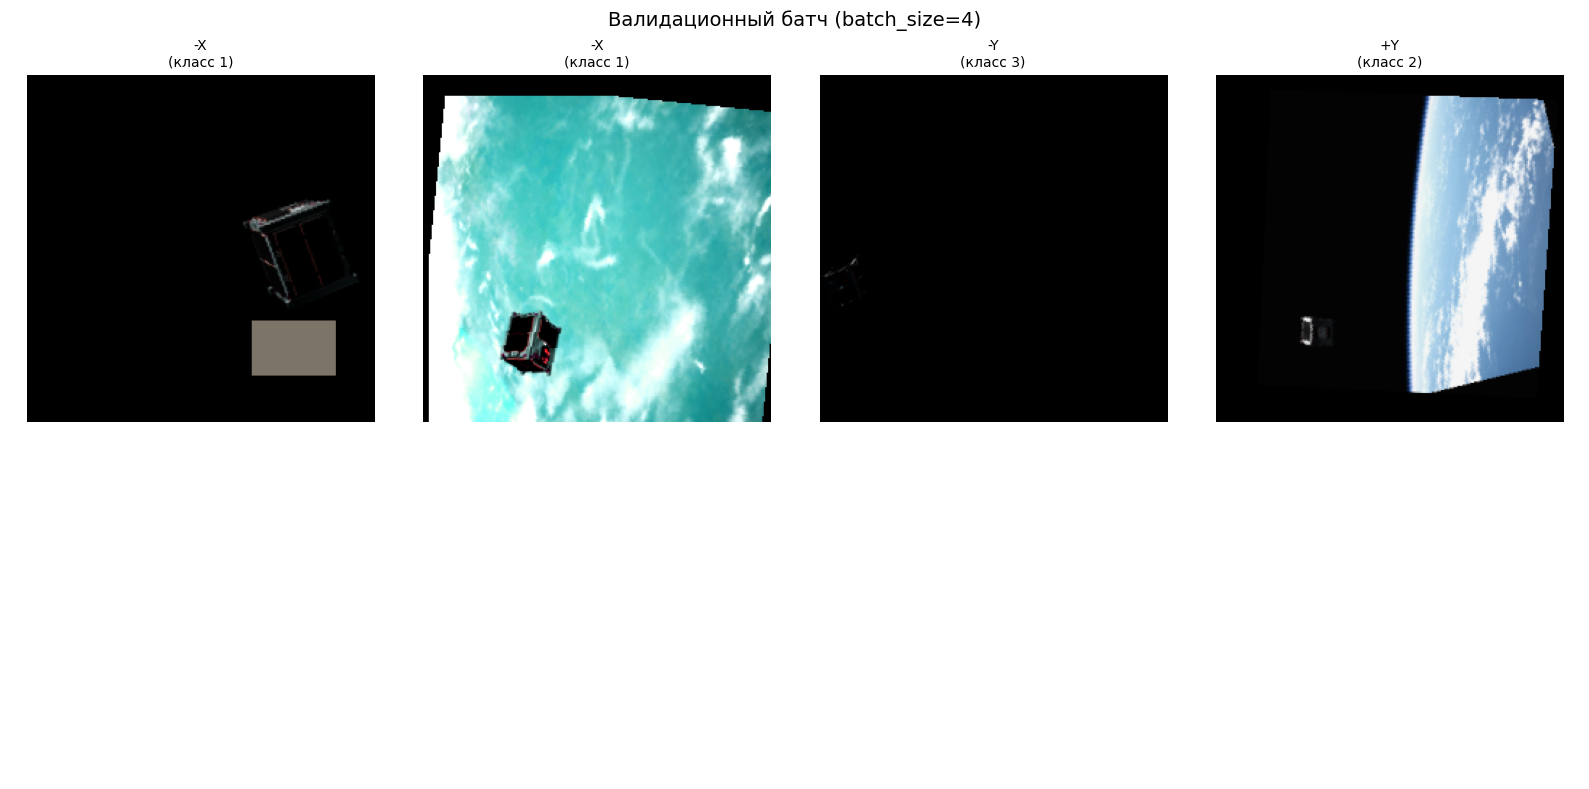


Тест загрузки нескольких батчей из каждого DataLoader...

Тестирование Train Loader:
   Батч 0: загружен за 0.26 сек, размер: torch.Size([4, 3, 240, 240])
   Батч 1: загружен за 0.28 сек, размер: torch.Size([4, 3, 240, 240])
   Батч 2: загружен за 0.26 сек, размер: torch.Size([4, 3, 240, 240])
   Среднее время загрузки батча: 0.27 сек
   Общее время: 0.80 сек

Тестирование Val Loader:
   Батч 0: загружен за 0.10 сек, размер: torch.Size([4, 3, 240, 240])
   Батч 1: загружен за 0.26 сек, размер: torch.Size([4, 3, 240, 240])
   Батч 2: загружен за 0.30 сек, размер: torch.Size([4, 3, 240, 240])
   Среднее время загрузки батча: 0.22 сек
   Общее время: 0.66 сек

   Статистика кэша после теста:
   Попаданий в кэш: 4
   Промахов кэша: 20
   Эффективность кэша: 16.7%
   Размер кэша: 33 изображений

Создание тестового датасета...
Загружен ground truth файл: ./synthetic_cubesat\dataset\test\test_ground_truth.csv
Колонки в ground truth: ['IMG_NUM', 'X', 'Y', 'Z', 'ROLL', 'PITCH', 'YAW', 'Q1', 'Q

In [2]:
import time
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torchvision import transforms
import os

simple_transformations = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])


transformations = transforms.Compose([
    transforms.Resize((240, 240)), 
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
])


dataset_root = './synthetic_cubesat'
try:
    print()
    print("Создание датасета с ленивой загрузкой...")
    start_time = time.time()
    
    full_train_dataset = CubeSatFaceDatasetLazy(
        root_dir=dataset_root,
        mode='train',
        transform=transformations,
        cache_size=50 
    )
    
    print(f"Датасет создан за {time.time() - start_time:.2f} секунд")
    
    print()
    print("Разделение на тренировочную и валидационную части...")
    train_size = int(0.8 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    train_dataset, val_dataset = random_split(
        full_train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    print(f"Тренировочных семплов: {len(train_dataset)} ({100*train_size/len(full_train_dataset):.0f}%)")
    print(f"Валидационных семплов: {len(val_dataset)} ({100*val_size/len(full_train_dataset):.0f}%)")
    
    print()
    print("Анализ распределения классов:")

    
    def analyze_class_distribution(dataset, name, original_dataset=full_train_dataset):
        print(f"{name} адтасет:")
        
        if hasattr(dataset, 'indices'):
            # Это Subset из random_split
            class_counts = {}
            for idx in dataset.indices:
                label = original_dataset.labels[idx]
                class_counts[label] = class_counts.get(label, 0) + 1
        else:
            # Это полный датасет
            class_counts = {}
            for i in range(len(dataset)):
                label = dataset.labels[i]
                class_counts[label] = class_counts.get(label, 0) + 1
        
        # Выводим статистику
        for label in sorted(class_counts.keys()):
            count = class_counts[label]
            percentage = 100 * count / len(dataset)
            face_name = full_train_dataset.get_face_name(label)
            print(f"  {face_name} (класс {label}): {count} ({percentage:.1f}%)")
        
        return class_counts
    
    full_dist = analyze_class_distribution(full_train_dataset, "Полный тренировочный")
    train_dist = analyze_class_distribution(train_dataset, "Тренировочный", full_train_dataset)
    val_dist = analyze_class_distribution(val_dataset, "Валидационный", full_train_dataset)
    
    print()
    print("Информация о первых 3 семплах из каждого раздела:")
    
    for dataset_name, dataset in [("Тренировочный", train_dataset), ("Валидационный", val_dataset)]:
        print(f"\n{dataset_name} датасет:")
        for i in range(min(3, len(dataset))):
            if hasattr(dataset, 'indices'):
                orig_idx = dataset.indices[i]
                info = full_train_dataset.get_sample_info(orig_idx)
            else:
                info = dataset.get_sample_info(i)
            
            print()
            print(f"    Семпл {i}:")
            print(f"    Путь: {os.path.basename(info['image_path'])}")
            print(f"    Метка: {info['label']} ({info['face_name']})")
    
    print()
    print("Тест загрузки одного изображения из каждого раздела:")
    
    for dataset_name, dataset in [("Тренировочный", train_dataset), ("Валидационный", val_dataset)]:
        print()
        print(f"{dataset_name} датасет:")
        test_start = time.time()
        
        if hasattr(dataset, 'indices'):
            orig_idx = dataset.indices[0]
            test_image, test_label = full_train_dataset[orig_idx]
        else:
            test_image, test_label = dataset[0]
        
        test_time = time.time() - test_start
        
        print(f"  Загружено за {test_time:.3f} секунд")
        print(f"  Размер изображения: {test_image.shape}")
        print(f"  Метка: {test_label} ({full_train_dataset.get_face_name(test_label)})")
    
    print()
    print("  Первая загрузка 5 изображений из тренировочного набора...")
    
    load_times = []
    for i in range(5):
        if hasattr(train_dataset, 'indices'):
            orig_idx = train_dataset.indices[i]
            start = time.time()
            img, label = full_train_dataset[orig_idx]
        else:
            start = time.time()
            img, label = train_dataset[i]
        
        load_time = time.time() - start
        load_times.append(load_time)
        print(f"  Семпл {i}: {load_time:.3f} сек")
    
    print(f"  Среднее время: {np.mean(load_times):.3f} сек")
    
    cache_stats = full_train_dataset.get_cache_stats()
    print()
    print(f"    Статистика кэша:")
    print(f"    Попаданий: {cache_stats['hits']}")
    print(f"    Промахов: {cache_stats['misses']}")
    print(f"    Эффективность: {cache_stats['hit_rate']:.1%}")
    
except Exception as e:
    print(f"Ошибка при создании датасета: {e}")
    import traceback
    traceback.print_exc()

if 'train_dataset' in locals() and 'val_dataset' in locals():
    try:
        BATCH_SIZE = 4  
        NUM_WORKERS = 0  
        
        print()
        print(f"Создание DataLoader'ов с параметрами:")
        print(f"   Batch size: {BATCH_SIZE}")
        print(f"   Num workers: {NUM_WORKERS}")
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,  
            num_workers=NUM_WORKERS,
            pin_memory=False, 
            drop_last=False,
            prefetch_factor=None,
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False, 
            num_workers=NUM_WORKERS,
            pin_memory=False,
            drop_last=False,
            prefetch_factor=None,
        )
        
        print(f" Train DataLoader создан: {len(train_loader)} батчей")
        print(f" Validation DataLoader создан: {len(val_loader)} батчей")

        
        def load_single_batch(data_loader, loader_name="DataLoader", max_attempts=3):
            for attempt in range(max_attempts):
                try:
                    print(f"\n[{loader_name}] Попытка {attempt + 1}...")
                    start_time = time.time()
                    
                    # Создаем итератор и получаем первый батч
                    data_iterator = iter(data_loader)
                    batch = next(data_iterator)
                    
                    # Проверяем структуру батча
                    if isinstance(batch, (list, tuple)) and len(batch) == 2:
                        images, labels = batch
                    elif isinstance(batch, dict):
                        images = batch.get('image', batch.get('images'))
                        labels = batch.get('label', batch.get('labels'))
                    else:
                        print(f"Неизвестная структура батча: {type(batch)}")
                        continue
                    
                    load_time = time.time() - start_time
                    print(f" Успешно загружено за {load_time:.2f} секунд")
                    
                    return images, labels
                    
                except StopIteration:
                    print(f"[{loader_name}] DataLoader пуст")
                    return None, None
                    
                except Exception as e:
                    print(f"✗ Ошибка: {e}")
            
            print(f"[{loader_name}] Все завершилось ошибкой")
            return None, None
        
        print()
        print("Тестирование тренировочного DataLoader...")
        train_images, train_labels = load_single_batch(train_loader, "Train Loader")
        
        if train_images is not None:
            print()
            print(f"   Информация о тренировочном батче:")
            print(f"   Размер изображений: {train_images.shape}")  # [B, C, H, W]
            print(f"   Размер меток: {train_labels.shape}")        # [B]
            print(f"   Потребление памяти: {train_images.element_size() * train_images.nelement() / 1024**2:.1f} МБ")
        
    
        print()
        print("Тестирование валидационного DataLoader...")
        val_images, val_labels = load_single_batch(val_loader, "Val Loader")
        
        if val_images is not None:
            print(f"\nИнформация о валидационном батче:")
            print(f"   Размер изображений: {val_images.shape}")
            print(f"   Размер меток: {val_labels.shape}")
            
            print()
            print("Сравнение тренировочного и валидационного наборов:")
            
            train_unique = torch.unique(train_labels) if train_labels is not None else []
            val_unique = torch.unique(val_labels) if val_labels is not None else []
            
            print(f"   Уникальные метки в тренировочном батче: {train_unique.tolist()}")
            print(f"   Уникальные метки в валидационном батче: {val_unique.tolist()}")

            
            print()
            print("Визуализация батчей...")

            
            def visualize_batch(images, labels, title, original_dataset=full_train_dataset):
                if images is None or labels is None:
                    return
                
                mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
                images_denorm = images * std + mean
                
                num_images_to_show = min(8, len(images))
                fig, axes = plt.subplots(2, 4, figsize=(16, 8))
                axes = axes.flatten()
                
                for i in range(num_images_to_show):
                    img = images_denorm[i].permute(1, 2, 0).cpu().numpy()
                    img = np.clip(img, 0, 1)
                    
                    label = labels[i].item()
                    face_name = original_dataset.get_face_name(label)
                    
                    axes[i].imshow(img)
                    axes[i].set_title(f'{face_name}\n(класс {label})', fontsize=10)
                    axes[i].axis('off')
                
                for i in range(num_images_to_show, len(axes)):
                    axes[i].axis('off')
                
                plt.suptitle(title, fontsize=14)
                plt.tight_layout()
                plt.show()
            
            visualize_batch(train_images, train_labels, 
                          f'Тренировочный батч (batch_size={BATCH_SIZE})', full_train_dataset)
            
            visualize_batch(val_images, val_labels, 
                          f'Валидационный батч (batch_size={BATCH_SIZE})', full_train_dataset)

            
            print()
            print("Тест загрузки нескольких батчей из каждого DataLoader...")
            full_train_dataset._reset_cache_stats()
            
            def test_multiple_batches(data_loader, loader_name, num_batches=3):
                print(f"\nТестирование {loader_name}:")
                batch_times = []
                
                test_iterator = iter(data_loader)
                
                for batch_idx in range(num_batches):
                    try:
                        start_time = time.time()
                        batch_images, batch_labels = next(test_iterator)
                        batch_time = time.time() - start_time
                        batch_times.append(batch_time)
                        
                        print(f"   Батч {batch_idx}: загружен за {batch_time:.2f} сек, "
                              f"размер: {batch_images.shape}")
                              
                    except StopIteration:
                        print(f"   Достигнут конец датасета после {batch_idx} батчей")
                        break
                    except Exception as e:
                        print(f"   Ошибка при загрузке батча {batch_idx}: {e}")
                        break
                
                if batch_times:
                    print(f"   Среднее время загрузки батча: {np.mean(batch_times):.2f} сек")
                    print(f"   Общее время: {np.sum(batch_times):.2f} сек")
                
                return batch_times
            
            train_batch_times = test_multiple_batches(train_loader, "Train Loader", 3)
            val_batch_times = test_multiple_batches(val_loader, "Val Loader", 3)
            
            cache_stats = full_train_dataset.get_cache_stats()
            print()
            print(f"   Статистика кэша после теста:")
            print(f"   Попаданий в кэш: {cache_stats['hits']}")
            print(f"   Промахов кэша: {cache_stats['misses']}")
            print(f"   Эффективность кэша: {cache_stats['hit_rate']:.1%}")
            print(f"   Размер кэша: {cache_stats['cache_size']} изображений")
        
        else:
            print("Не удалось загрузить батч")
            
    except Exception as e:
        print(f"Ошибка при создании DataLoader: {e}")
        import traceback
        traceback.print_exc()

try:
    print()
    print("Создание тестового датасета...")
    
    test_dataset_lazy = CubeSatFaceDatasetLazy(
        root_dir=dataset_root,
        mode='test',
        transform=transformations,
        cache_size=30
    )
    
    print(f"   Тестовый датасет создан: {len(test_dataset_lazy)} изображений")
    
    print()
    print("Распределение классов в тестовом наборе:")
    class_counts = {}
    for i in range(len(test_dataset_lazy)):
        label = test_dataset_lazy.labels[i]
        class_counts[label] = class_counts.get(label, 0) + 1
    
    sorted_classes = sorted(class_counts.items(), key=lambda x: test_dataset_lazy.get_face_name(x[0]))
    
    for label, count in sorted_classes:
        face_name = test_dataset_lazy.get_face_name(label)
        percentage = count / len(test_dataset_lazy) * 100
        print(f"   {face_name} (класс {label}): {count} ({percentage:.1f}%)")
    
  
    print()
    print("Создание DataLoader для теста...")
    
    test_loader = DataLoader(
        test_dataset_lazy,
        batch_size=128,
        shuffle=False,  # Не перемешиваем тестовые данные
        num_workers=0,
        pin_memory=False
    )
    
    print("   Тестовый DataLoader создан")
    
except Exception as e:
    print(f"Ошибка при создании тестового датасета: {e}")
    import traceback
    traceback.print_exc()

if 'train_dataset' in locals() and 'val_dataset' in locals():
    print()
    print("ИТОГИ:")
    
    print()
    print("Размеры датасетов:")
    print(f"  • Тренировочный: {len(train_dataset)} изображений")
    print(f"  • Валидационный: {len(val_dataset)} изображений")
    print(f"  • Тестовый: {len(test_dataset_lazy) if 'test_dataset_lazy' in locals() else 0} изображений")
    
    print()
    print("Параметры DataLoader:")
    print(f"  • Batch size: {BATCH_SIZE}")
    print(f"  • Num workers: {NUM_WORKERS}")
    
    print()
    print("Рекомендуемые параметры для обучения:")
    print("  • Batch size: 8-16 (в зависимости от доступной памяти)")
    print(f"  • Num workers: 2-4 (если достаточно CPU ядер)")
    print(f"  • Pin memory: {'True' if torch.cuda.is_available() else 'False'}")
    
    if torch.cuda.is_available():
        print("  • CUDA доступна: Да")
        print(f"  • Устройство: {torch.cuda.get_device_name(0)}")
        print(f"  • Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} ГБ")
    else:
        print(f"  • CUDA доступна: Нет, используем CPU")
    
    print()
    print(f"Оценка потребления памяти:")
    
    # Для batch_size=8, изображения 128x128x3
    image_size_mb = 8 * 3 * 128 * 128 * 4 / 1024**2  # float32 = 4 байта
    print(f"  • Один батч (8 изображений 128x128): {image_size_mb:.1f} МБ")
    
    # Для кэша
    cache_size_mb = 50 * 3 * 128 * 128 * 4 / 1024**2
    print(f"  • Кэш (50 изображений): {cache_size_mb:.1f} МБ")
    

print("DONE")

 Анализ статистик датасета

In [3]:
def analyze_dataset_statistics(dataset, name="Dataset"):
    print(f"Анализ статистик: {name}")
    
    
    print(f"Общая инфомация:")
    print(f"    Всего изображений: {len(dataset)}")
    
    if hasattr(dataset, 'dataset') and hasattr(dataset, 'indices'):
        original_dataset = dataset.dataset
        indices = dataset.indices
        is_subset = True
        print(f"  Тип: Subset (индексы: {len(indices)} из {len(original_dataset)})")
    else:
        original_dataset = dataset
        indices = list(range(len(dataset)))
        is_subset = False
        print(f"  Тип: Полный датасет")
    
    if len(dataset) > 0:
        try:
            if hasattr(original_dataset, 'image_files'):
                img_path = original_dataset.image_files[indices[0]]
                with Image.open(img_path) as img:
                    width, height = img.size
                    print(f"  Размер изображений: {width}x{height} пикселей")
                    
                    sizes = [(width, height)]
                    for i in range(1, min(10, len(indices))):
                        idx = indices[i]
                        with Image.open(original_dataset.image_files[idx]) as img2:
                            sizes.append(img2.size)
                    
                    unique_sizes = set(sizes)
        except Exception as e:
            print(f"  Ошибка: {e}")
    
    print()
    print(f"Анализ ground truth данных:")
    
    if hasattr(original_dataset, 'gt_df'):
        if is_subset:
            df = original_dataset.gt_df.iloc[indices].copy()
        else:
            df = original_dataset.gt_df.copy()
        
        print(f"  Всего записей: {len(df)}")
        print(f"  Колонки: {list(df.columns)}")
        
        numeric_cols = df.select_dtypes(include=[np.number]).columns

        print()
        print("Статистики числовых колонок:")
        for col in numeric_cols:
            if col not in ['IMG_NUM']:  
                print(f"    {col}:")
                print(f"      Min: {df[col].min():.4f}, Max: {df[col].max():.4f}")
                print(f"      Mean: {df[col].mean():.4f}, Std: {df[col].std():.4f}")
                
                # Проверка на NaN
                nan_count = df[col].isna().sum()
                if nan_count > 0:
                    print(f"      WARNING: {nan_count} NaN значений!")
        
        pos_cols = ['X', 'Y', 'Z']
        if all(col in df.columns for col in pos_cols):
            fig = plt.figure(figsize=(15, 5))
            
            for i, col in enumerate(pos_cols):
                plt.subplot(1, 3, i+1)
                plt.hist(df[col], bins=50, alpha=0.7, edgecolor='black')
                plt.xlabel(col)
                plt.ylabel('Частота')
                plt.title(f'Распределение {col}')
                plt.grid(True, alpha=0.3)
            
            plt.suptitle(f'Распределение позиционных параметров ({name})')
            plt.tight_layout()
            plt.show()
        
        quat_cols = ['Q1', 'Q2', 'Q3', 'W']
        if all(col in df.columns for col in quat_cols):
            fig = plt.figure(figsize=(15, 10))
            
            for i, col in enumerate(quat_cols):
                plt.subplot(2, 2, i+1)
                plt.hist(df[col], bins=50, alpha=0.7, edgecolor='black')
                plt.xlabel(col)
                plt.ylabel('Частота')
                plt.title(f'Распределение {col}')
                plt.grid(True, alpha=0.3)
            
            plt.suptitle(f'Распределение кватернионов ({name})')
            plt.tight_layout()
            plt.show()


    print()
    print("Анлиз меток:")
    
    if hasattr(original_dataset, 'labels'):
        if is_subset:
            if isinstance(original_dataset.labels, list):
                labels = [original_dataset.labels[i] for i in indices]
            elif isinstance(original_dataset.labels, torch.Tensor):
                labels = original_dataset.labels[indices]
            elif isinstance(original_dataset.labels, np.ndarray):
                labels = original_dataset.labels[indices]
            else:
                try:
                    labels_array = np.array(original_dataset.labels)
                    labels = labels_array[indices]
                except:
                    labels = [original_dataset.labels[i] for i in indices]
        else:
            labels = original_dataset.labels
        
        if isinstance(labels, torch.Tensor):
            labels = labels.numpy()
        elif isinstance(labels, list):
            labels = np.array(labels)
        
        unique_labels, counts = np.unique(labels, return_counts=True)
        
        if hasattr(original_dataset, 'get_face_name'):
            for label, count in zip(unique_labels, counts):
                face_name = original_dataset.get_face_name(label)
                percentage = count / len(dataset) * 100
                print(f"  {face_name} (класс {label}): {count} изображений ({percentage:.1f}%)")
        else:
            for label, count in zip(unique_labels, counts):
                percentage = count / len(dataset) * 100
                print(f"  Класс {label}: {count} изображений ({percentage:.1f}%)")
        
        plt.figure(figsize=(10, 6))
        if hasattr(original_dataset, 'get_face_name'):
            face_names = [original_dataset.get_face_name(l) for l in unique_labels]
        else:
            face_names = [f'Класс {l}' for l in unique_labels]
            
        bars = plt.bar(face_names, counts, color='skyblue', edgecolor='black')
        
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}\n({height/len(dataset)*100:.1f}%)',
                    ha='center', va='bottom', fontsize=9)
        
        plt.xlabel('Грань кубсата')
        plt.ylabel('Количество изображений')
        plt.title(f'Распределение классов ({name})')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        
        if len(counts) > 0:
            imbalance_ratio = max(counts) / min(counts) if min(counts) > 0 else float('inf')
            print(f"\nБаланс классов:")
            print(f"  Соотношение самого частого к самому редкому: {imbalance_ratio:.2f}:1")
    
    result = {
        'num_images': len(dataset),
        'is_subset': is_subset,
        'num_indices': len(indices) if is_subset else len(dataset),
    }
    
    if hasattr(original_dataset, 'labels') and 'unique_labels' in locals():
        if hasattr(original_dataset, 'get_face_name'):
            class_dist = {original_dataset.get_face_name(l): c 
                         for l, c in zip(unique_labels, counts)}
        else:
            class_dist = {f'class_{l}': c for l, c in zip(unique_labels, counts)}
        
        result['class_distribution'] = class_dist
        result['imbalance_ratio'] = imbalance_ratio
    
    if hasattr(original_dataset, 'gt_df') and 'df' in locals():
        pos_cols = ['X', 'Y', 'Z']
        position_stats = {}
        for col in pos_cols:
            if col in df.columns:
                position_stats[col] = {
                    'min': float(df[col].min()),
                    'max': float(df[col].max()),
                    'mean': float(df[col].mean()),
                    'std': float(df[col].std())
                }
        result['position_stats'] = position_stats
    
    return result

    
print("DONE")

DONE


Архитектура модели

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from efficientnet_pytorch import EfficientNet

class CubeSatFaceClassifier(nn.Module):
    
    def __init__(self, num_classes=6, pretrained=True):
        super().__init__()
        
        # Используем предобученный EfficientNet-B1 как базовую модель
        if pretrained:
            self.backbone = EfficientNet.from_pretrained('efficientnet-b1')
        else:
            self.backbone = EfficientNet.from_name('efficientnet-b1')
        
        # Получаем количество выходных каналов перед pooling слоем
        in_channels = self.backbone._conv_head.out_channels
        # Получаем размерность эмбеддинга после pooling
        self.embedding_size = self.backbone._fc.in_features
        
        # Заменяем классификатор EfficientNet на наш
        self.backbone._fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.embedding_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
        # Настраиваем attention слой под EfficientNet (меньше каналов)
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, 256, 1),  # EfficientNet-B1: 320 каналов
            nn.ReLU(),
            nn.Conv2d(256, 1, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x, return_attention=False):
        # Извлекаем фичи через EfficientNet до pooling слоя
        # EfficientNet использует другую структуру, чем ResNet
        
        # Пропускаем через начальные слои
        x = self.backbone._swish(self.backbone._bn0(self.backbone._conv_stem(x)))
        
        # Пропускаем через MBConv блоки
        for idx, block in enumerate(self.backbone._blocks):
            x = block(x)
        
        # Применяем финальную свертку
        x = self.backbone._swish(self.backbone._bn1(self.backbone._conv_head(x)))
        
        # Применяем наш attention механизм
        attention_map = self.attention(x)
        x = x * attention_map
        
        # Global pooling
        x = self.backbone._avg_pooling(x)
        x = x.flatten(start_dim=1)
        
        # Классификатор
        output = self.backbone._fc(x)
        
        if return_attention:
            return output, attention_map
        return output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CubeSatFaceClassifier(num_classes=6, pretrained=True).to(device)

print(model)
print(f"Число параметров: {sum(p.numel() for p in model.parameters()):,}")

Loaded pretrained weights for efficientnet-b1
CubeSatFaceClassifier(
  (backbone): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
 

Визуализация маркерных точек

Тест визуализации fiducial markers...
Размеры Attenshion map: torch.Size([1, 1, 8, 8])
Attenshion map до интерполяции: torch.Size([1, 1, 8, 8])


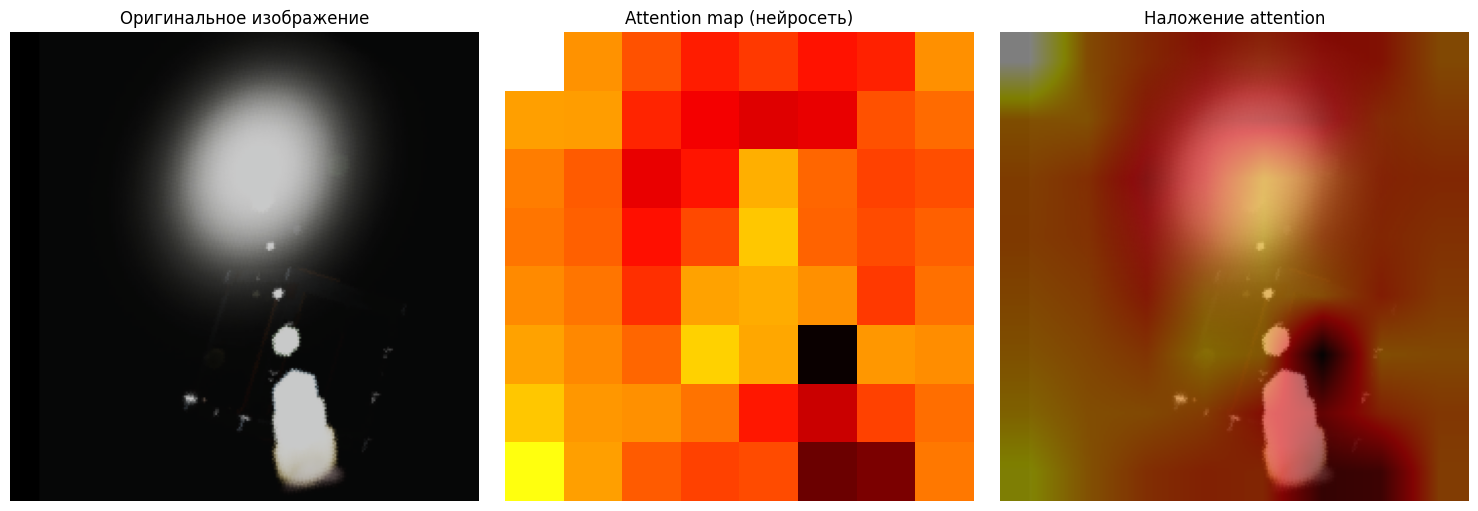

DONE


In [5]:
import torch.nn.functional as F

def visualize_fiducial_markers(image, attention_map=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Оригинальное изображение
    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)
    
    axes[0].imshow(img_np)
    axes[0].set_title('Оригинальное изображение')
    axes[0].axis('off')
    
    if attention_map is not None:
        print(f"Размеры Attenshion map: {attention_map.shape}")
        
        if attention_map.dim() == 5:  # [1, 1, 1, 8, 8]
            attention_map = attention_map.squeeze(0)
        elif attention_map.dim() == 4:  # [1, 1, 8, 8]
            attention_map = attention_map.squeeze(0)
        att_np = attention_map.squeeze().cpu().numpy()
        if att_np.ndim > 2:
            att_np = att_np.squeeze()
        
        axes[1].imshow(att_np, cmap='hot')
        axes[1].set_title('Attention map (нейросеть)')
        axes[1].axis('off')
    
    axes[2].imshow(img_np)
    if attention_map is not None:
        if attention_map.dim() == 2:  # [H, W]
            attention_map = attention_map.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
        elif attention_map.dim() == 3:  # [1, H, W] или [C, H, W]
            if attention_map.shape[0] == 1:  # [1, H, W]
                attention_map = attention_map.unsqueeze(0)  # [1, 1, H, W]
            else:  # [C, H, W]
                attention_map = attention_map.unsqueeze(0)  # [1, C, H, W]
        
        print(f"Attenshion map до интерполяции: {attention_map.shape}")
        
        att_resized = F.interpolate(
            attention_map, 
            size=img_np.shape[:2],  # (256, 256)
            mode='bilinear',
            align_corners=False
        )
        
        att_np_resized = att_resized.squeeze().cpu().numpy()
        
        if att_np_resized.ndim > 2:
            att_np_resized = att_np_resized.squeeze()
        
        axes[2].imshow(att_np_resized, cmap='hot', alpha=0.5)
    
    axes[2].set_title('Наложение attention')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Тест визуализации fiducial markers...")
test_image, test_label = train_dataset[0]
test_batch = test_image.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    _, attention_map = model(test_batch, return_attention=True)

visualize_fiducial_markers(test_image, attention_map)
    

print("DONE")

Функции обучения

In [7]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

class Trainer:
    def __init__(self, model, train_loader, val_loader, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        
        self.optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='max', 
                                         patience=3, factor=0.5, verbose=True)
        # self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


        class_counts = [427, 453, 191, 172, 176, 181]  # из confusion matrix
        class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
        class_weights = class_weights / class_weights.sum()
        self.criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

        
        # История обучения
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
            'learning_rate': []
        }
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)
            
            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            # Статистика
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            if batch_idx % 50 == 0:
                print(f'Batch {batch_idx}/{len(self.train_loader)}, '
                      f'Loss: {loss.item():.4f}, '
                      f'Acc: {100.*correct/total:.2f}%')
        
        avg_loss = total_loss / len(self.train_loader)
        accuracy = 100. * correct / total
        
        return avg_loss, accuracy
    
    def validate(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_loss = total_loss / len(self.val_loader)
        accuracy = 100. * correct / total
        
        return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)
    
    def train(self, num_epochs=50):
        best_acc = 0
        
        for epoch in range(num_epochs):
            print()
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 50)
            
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc, val_preds, val_labels = self.validate()
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['learning_rate'].append(
                self.optimizer.param_groups[0]['lr']
            )
            
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
            self.scheduler.step(val_acc)
            
            if val_acc > best_acc:
                best_acc = val_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_acc': val_acc,
                }, 'best_face_classifier.pth')
                print(f'Новая лучшая модель сохранена с точностью {val_acc:.2f}%')
            
            if self.optimizer.param_groups[0]['lr'] < 1e-6:
                print("Learning rate слишком низкий, останавливаем обучение")
                break
        
        return self.history

trainer = Trainer(model, train_loader, val_loader, device)
history = trainer.train(num_epochs=25)


    

print("DONE")


Epoch 1/25
--------------------------------------------------
Batch 0/1600, Loss: 1.8060, Acc: 25.00%
Batch 50/1600, Loss: 1.7373, Acc: 22.06%
Batch 100/1600, Loss: 1.7844, Acc: 18.32%
Batch 150/1600, Loss: 1.7637, Acc: 19.37%
Batch 200/1600, Loss: 1.7775, Acc: 18.41%
Batch 250/1600, Loss: 1.8200, Acc: 19.32%
Batch 300/1600, Loss: 1.7780, Acc: 19.85%
Batch 350/1600, Loss: 1.8414, Acc: 20.30%
Batch 400/1600, Loss: 1.9888, Acc: 20.26%
Batch 450/1600, Loss: 2.1677, Acc: 20.62%
Batch 500/1600, Loss: 1.8950, Acc: 21.21%
Batch 550/1600, Loss: 1.6034, Acc: 21.69%
Batch 600/1600, Loss: 2.1706, Acc: 22.59%
Batch 650/1600, Loss: 1.3627, Acc: 23.16%
Batch 700/1600, Loss: 1.7182, Acc: 23.89%
Batch 750/1600, Loss: 1.3109, Acc: 24.27%
Batch 800/1600, Loss: 1.4183, Acc: 24.38%
Batch 850/1600, Loss: 1.7618, Acc: 25.06%
Batch 900/1600, Loss: 1.3488, Acc: 25.61%
Batch 950/1600, Loss: 1.6336, Acc: 25.81%
Batch 1000/1600, Loss: 1.5722, Acc: 26.27%
Batch 1050/1600, Loss: 1.5732, Acc: 26.71%
Batch 1100/160

Визуализация процесса обучения

C:\Users\Roman\AppData\Local\Temp\ipykernel_13764\2864593736.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_face_classifier.pth')


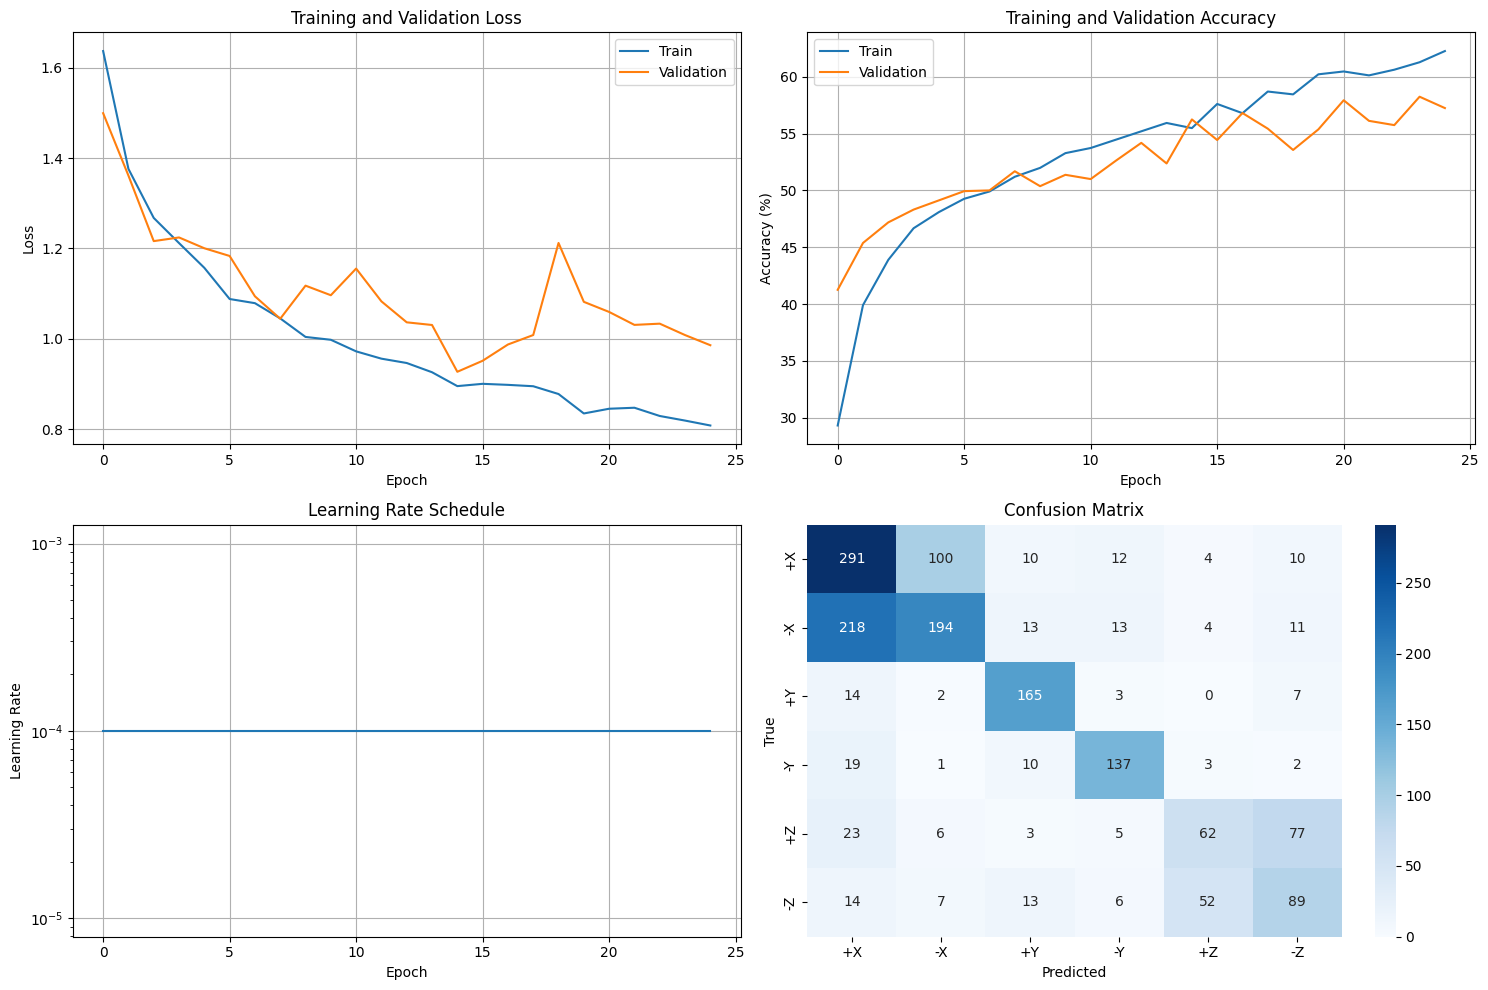


Classification Report:
              precision    recall  f1-score   support

          +X       0.50      0.68      0.58       427
          -X       0.63      0.43      0.51       453
          +Y       0.77      0.86      0.81       191
          -Y       0.78      0.80      0.79       172
          +Z       0.50      0.35      0.41       176
          -Z       0.45      0.49      0.47       181

    accuracy                           0.59      1600
   macro avg       0.60      0.60      0.60      1600
weighted avg       0.59      0.59      0.58      1600

DONE


In [8]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train')
    axes[0, 0].plot(history['val_loss'], label='Validation')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train')
    axes[0, 1].plot(history['val_acc'], label='Validation')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Learning rate
    axes[1, 0].plot(history['learning_rate'])
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].grid(True)
    axes[1, 0].set_yscale('log')
    
    # Confusion matrix
    checkpoint = torch.load('best_face_classifier.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    _, _, val_preds, val_labels = trainer.validate()
    
    cm = confusion_matrix(val_labels, val_preds)
    face_names = ['+X', '-X', '+Y', '-Y', '+Z', '-Z']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=face_names, yticklabels=face_names,
                ax=axes[1, 1])
    axes[1, 1].set_xlabel('Predicted')
    axes[1, 1].set_ylabel('True')
    axes[1, 1].set_title('Confusion Matrix')
    
    plt.tight_layout()
    plt.show()
    
    print()
    print("Classification Report:")
    print(classification_report(val_labels, val_preds, 
                              target_names=face_names))

plot_training_history(history)


print("DONE")

Метрики качества

In [9]:
def evaluate_model(model, data_loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    accuracy = np.mean(all_preds == all_labels)
    
    face_names = ['+X', '-X', '+Y', '-Y', '+Z', '-Z']
    class_report = classification_report(all_labels, all_preds,
                                        target_names=face_names,
                                        output_dict=True)
    
    confidences = all_probs[np.arange(len(all_preds)), all_preds]
    avg_confidence = np.mean(confidences)
    
    print(f"Общая точность: {accuracy*100:.2f}%")
    print(f"Средняя уверенность: {avg_confidence:.3f}")
    print()
    print("Метрики по классам:")
    
    for i, face in enumerate(face_names):
        precision = class_report[face]['precision']
        recall = class_report[face]['recall']
        print(f"{face}: Precision={precision:.3f}, Recall={recall:.3f}")
    
    return {
        'accuracy': accuracy,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'class_report': class_report
    }

print("Оценка на тестовом наборе (random-sample):")
test_results = evaluate_model(model, val_loader, device)

print("DONE")

Оценка на тестовом наборе (random-sample):
Общая точность: 59.69%
Средняя уверенность: 0.707

Метрики по классам:
+X: Precision=0.511, Recall=0.693
-X: Precision=0.637, Recall=0.430
+Y: Precision=0.766, Recall=0.874
-Y: Precision=0.771, Recall=0.785
+Z: Precision=0.548, Recall=0.392
-Z: Precision=0.474, Recall=0.514
DONE


 Анализ ошибок

Найдено 672 ошибок
Топ-5 наиболее уверенных ошибок:


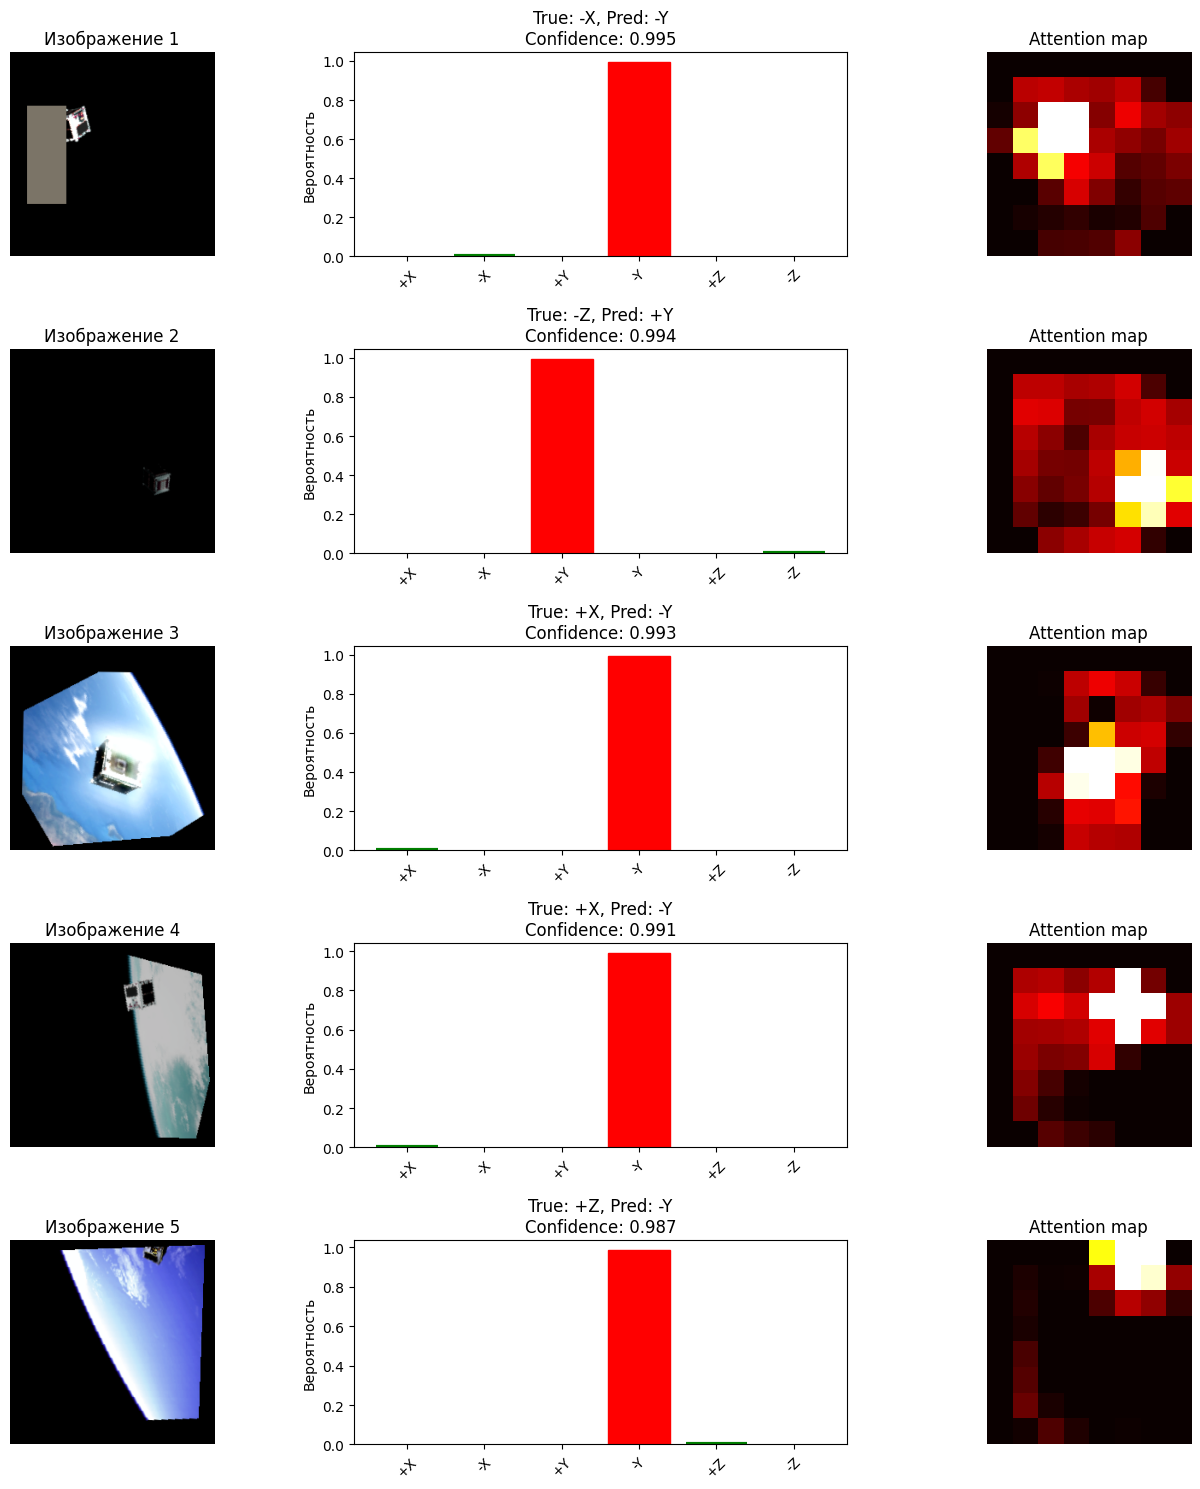


Tолько ошибочные предсказания:


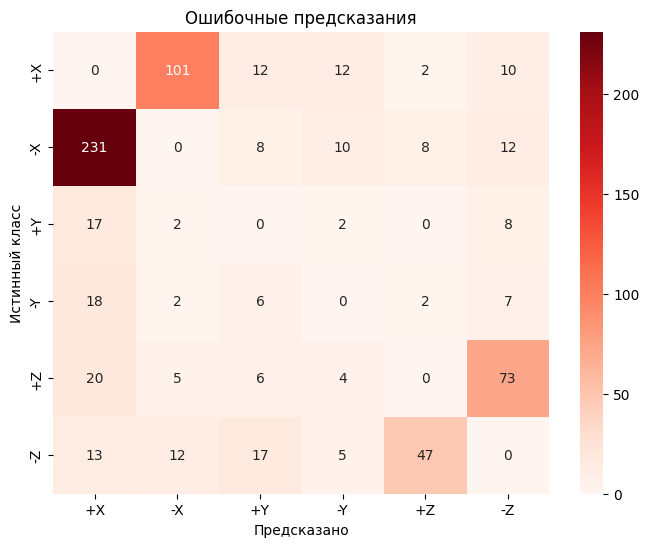

DONE


In [10]:
def analyze_errors(model, data_loader, device, num_samples=5):
    model.eval()
    errors = []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            for i in range(len(labels)):
                if preds[i].item() != labels[i].item():
                    errors.append({
                        'image': images[i].cpu(),
                        'true_label': labels[i].item(),
                        'pred_label': preds[i].item(),
                        'probabilities': probs[i].cpu().numpy(),
                        'confidence': probs[i][preds[i]].item()
                    })
    
    errors.sort(key=lambda x: x['confidence'], reverse=True)
    print(f"Найдено {len(errors)} ошибок")
    print(f"Топ-{num_samples} наиболее уверенных ошибок:")
    face_names = ['+X', '-X', '+Y', '-Y', '+Z', '-Z']
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 3*num_samples))
    for i in range(min(num_samples, len(errors))):
        error = errors[i]
        
        img_np = error['image'].permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Изображение {i+1}')
        axes[i, 0].axis('off')
        probs = error['probabilities']
        bars = axes[i, 1].bar(range(len(probs)), probs)
        
        pred_idx = error['pred_label']
        true_idx = error['true_label']
        bars[pred_idx].set_color('red')
        bars[true_idx].set_edgecolor('green')
        bars[true_idx].set_linewidth(3)
        
        axes[i, 1].set_xticks(range(len(face_names)))
        axes[i, 1].set_xticklabels(face_names, rotation=45)
        axes[i, 1].set_ylabel('Вероятность')
        axes[i, 1].set_title(f'True: {face_names[true_idx]}, '
                           f'Pred: {face_names[pred_idx]}\n'
                           f'Confidence: {error["confidence"]:.3f}')
        
        # Attention map
        with torch.no_grad():
            _, attention = model(error['image'].unsqueeze(0).to(device), 
                               return_attention=True)
            att_np = attention.squeeze().cpu().numpy()
            axes[i, 2].imshow(att_np, cmap='hot')
            axes[i, 2].set_title('Attention map')
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

    error_by_class = {}
    for error in errors:
        true_class = error['true_label']
        pred_class = error['pred_label']
        
        key = (true_class, pred_class)
        error_by_class[key] = error_by_class.get(key, 0) + 1

    print()
    print("Tолько ошибочные предсказания:")
    error_matrix = np.zeros((6, 6))
    for (true, pred), count in error_by_class.items():
        error_matrix[true, pred] = count
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(error_matrix, annot=True, fmt='g', cmap='Reds',
                xticklabels=face_names, yticklabels=face_names)
    plt.title('Oшибочные предсказания')
    plt.xlabel('Предсказано')
    plt.ylabel('Истинный класс')
    plt.show()

analyze_errors(model, val_loader, device, num_samples=5)
print("DONE")